In [1]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json

In [11]:
current_directory = Path.cwd().parent
discharge_directory = Path.joinpath(current_directory, "Data Start Point")

compiled_file_name = Path.joinpath(discharge_directory, "compiled_output.csv")
output_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(discharge_directory, "points_of_interest.json")

def create_csv_output_file(override=False, csv_data=None):
    if override and Path.exists(output_file_name):
        Path.unlink(output_file_name)
    
    if csv_data is not None:
        csv_data.to_csv(output_file_name, mode='a', header=not Path.exists(output_file_name), index=False)

In [21]:
combined_df = pd.read_csv(compiled_file_name)
print(combined_df.shape)
print(combined_df.head())

(623042, 8)
   Translated Time  Translated Time (minutes)  \
0             1000                   0.016667   
1             1032                   0.017200   
2             1064                   0.017733   
3             1095                   0.018250   
4             1126                   0.018767   

   ADS Reading 1 (Smoothed and Offset)  Calibrated Current 1  \
0                             2.863429              0.008564   
1                            -1.136571             -0.003399   
2                             1.863429              0.005573   
3                             1.863429              0.005573   
4                            -3.136571             -0.009381   

   ADS Reading 2 (Smoothed and Offset)  Calibrated Current 2  \
0                             4.816303              0.014406   
1                             4.816303              0.014406   
2                             4.816303              0.014406   
3                             4.816303              

In [ ]:
CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD = 0.3
prev_found_time = -999

# Tuple of time (min) and voltage
last_stable_voltages_before_close = {"index": [], "time": [], "voltage": []}
for index in range(20, len(combined_df) - 1000):
    if index % 10000 == 0:
        print(f"Processing index {index}/{len(combined_df)}", end="\r")   
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        curr = combined_df['Calibrated Voltage'].iloc[index]    # Current point
        following = combined_df['Calibrated Voltage'].iloc[index:index+5].mean() # Avg of next few point to confirm it is the edge
        next = combined_df['Calibrated Voltage'].iloc[index+500:index+1000].max() # Ensure that drop is not due to noise
        
        if curr - following > 0.01 and curr > next + CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD:
            print(f"Found potential circuit close at index {index} with voltage drop from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit close
            last_stable_voltages_before_close['index'].append(index)
            last_stable_voltages_before_close['time'].append(combined_df["Translated Time (minutes)"].iloc[index-20:index].mean())
            last_stable_voltages_before_close['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-20:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    
print("Found", len(last_stable_voltages_before_close['time']), "points\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t")
is_close_filtered = False
is_open_filtered = False

Found potential circuit close at index 237 with voltage drop from 58.20 V to 56.29 V at time 0.22 min.
Found potential circuit close at index 32509 with voltage drop from 57.06 V to 55.43 V at time 27.83 min.
Found potential circuit close at index 95076 with voltage drop from 56.33 V to 54.62 V at time 75.09 min.
Found potential circuit close at index 157482 with voltage drop from 55.41 V to 53.67 V at time 120.48 min.
Found potential circuit close at index 206298 with voltage drop from 54.10 V to 52.21 V at time 163.26 min.
Found potential circuit close at index 246533 with voltage drop from 53.12 V to 51.49 V at time 194.56 min.
Found potential circuit close at index 279795 with voltage drop from 52.38 V to 50.83 V at time 221.34 min.
Found potential circuit close at index 318876 with voltage drop from 51.80 V to 50.22 V at time 253.56 min.
Found potential circuit close at index 377440 with voltage drop from 51.35 V to 49.79 V at time 298.13 min.
Found potential circuit close at inde

In [105]:
print(last_stable_voltages_before_close['time'])
print(last_stable_voltages_before_close['voltage'])
to_drop = []
for index in range(1, len(last_stable_voltages_before_close['time'])):
    if last_stable_voltages_before_close['voltage'][index] > last_stable_voltages_before_close['voltage'][index-1]:
        curr_voltage = last_stable_voltages_before_close['voltage'][index]
        for i in range(index):
            if last_stable_voltages_before_close['voltage'][i] < curr_voltage:
                to_drop.append(i)

print("Dropping indices", to_drop)
last_stable_voltages_before_close['time'] = [time for i, time in enumerate(last_stable_voltages_before_close['time']) if i not in to_drop]
last_stable_voltages_before_close['voltage'] = [voltage for i, voltage in enumerate(last_stable_voltages_before_close['voltage']) if i not in to_drop]
print("After dropping, found", len(last_stable_voltages_before_close['time']), "points")

[np.float64(0.021642500000000002), np.float64(27.4721975), np.float64(74.6692725), np.float64(120.35258000000002), np.float64(121.35286), np.float64(124.04755333333333), np.float64(162.81393333333335), np.float64(167.10720083333334), np.float64(194.21153333333334), np.float64(221.00197500000004), np.float64(253.09399916666666), np.float64(297.73356833333327), np.float64(336.9275966666667), np.float64(381.5558158333334), np.float64(426.1052216666667), np.float64(466.5450158333334), np.float64(475.86219666666665), np.float64(476.8614033333332), np.float64(509.2963925), np.float64(510.2945849999999), np.float64(511.29652999999996), np.float64(512.2992233333333), np.float64(513.2975675)]
[np.float64(58.20104818239796), np.float64(57.049507653061234), np.float64(56.33308469387755), np.float64(55.405996014030634), np.float64(53.076482047193885), np.float64(52.5627493622449), np.float64(54.10178265306123), np.float64(51.80565162627552), np.float64(53.1233093112245), np.float64(52.382390338010

In [5]:
CIRCUIT_OPEN_VOLTAGE_JUMP_THRESHOLD = 0.5
prev_found_time = -999
# Tuple of time (min) and voltage
last_stable_voltages_before_open = {"index": [], "time": [], "voltage": []}

for index in range(20, len(combined_df)-500): 
    if index % 1000 == 0:
        print(f"Processing index {index}/{len(combined_df)}", end="\r")   
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        curr = combined_df['Calibrated Voltage'].iloc[index]
        next = combined_df['Calibrated Voltage'].iloc[index+200:index+500].min()
        following = combined_df['Calibrated Voltage'].iloc[index+1:index+5].mean() # Avg of next few point to confirm it is the edge
        
        if following - curr > 0.1 and next - curr > CIRCUIT_OPEN_VOLTAGE_JUMP_THRESHOLD:
            print(f"Found potential circuit open at index {index} with voltage jump from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit open
            last_stable_voltages_before_open['index'].append(index)
            last_stable_voltages_before_open['time'].append(combined_df["Translated Time (minutes)"].iloc[index-20:index].mean())
            last_stable_voltages_before_open['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-20:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    
print("Found", len(last_stable_voltages_before_open['time']), "points")

Found potential circuit open at index 13297 with voltage jump from 55.40 V to 56.63 V at time 10.85 min.
Found potential circuit open at index 46691 with voltage jump from 54.58 V to 55.71 V at time 38.81 min.
Found potential circuit open at index 112353 with voltage jump from 53.57 V to 54.71 V at time 87.62 min.
Found potential circuit open at index 168972 with voltage jump from 52.25 V to 53.56 V at time 131.70 min.
Found potential circuit open at index 220705 with voltage jump from 51.48 V to 52.71 V at time 174.48 min.
Found potential circuit open at index 256857 with voltage jump from 50.82 V to 51.98 V at time 204.54 min.
Found potential circuit open at index 294521 with voltage jump from 50.18 V to 51.34 V at time 232.42 min.
Found potential circuit open at index 335284 with voltage jump from 49.60 V to 50.78 V at time 266.13 min.
Found potential circuit open at index 391790 with voltage jump from 49.23 V to 50.25 V at time 309.15 min.
Found potential circuit open at index 4360

In [46]:
# Drop last 4 points from visual inspection of before circuit close
POINTS_TO_DROP = 1
if not is_close_filtered:
    last_stable_voltages_before_close['time'] = last_stable_voltages_before_close['time'][:-POINTS_TO_DROP]
    last_stable_voltages_before_close['voltage'] = last_stable_voltages_before_close['voltage'][:-POINTS_TO_DROP] 
    last_stable_voltages_before_close['index'] = last_stable_voltages_before_close['index'][:-POINTS_TO_DROP]
    is_close_filtered = True

In [47]:
# Drop last 4 points from visual inspection of before circuit open
POINTS_TO_DROP = 1
if not is_open_filtered:
    last_stable_voltages_before_open['time'] = last_stable_voltages_before_open['time'][:-POINTS_TO_DROP]
    last_stable_voltages_before_open['voltage'] = last_stable_voltages_before_open['voltage'][:-POINTS_TO_DROP] 
    last_stable_voltages_before_open['index'] = last_stable_voltages_before_open['index'][:-POINTS_TO_DROP]
    is_open_filtered = True

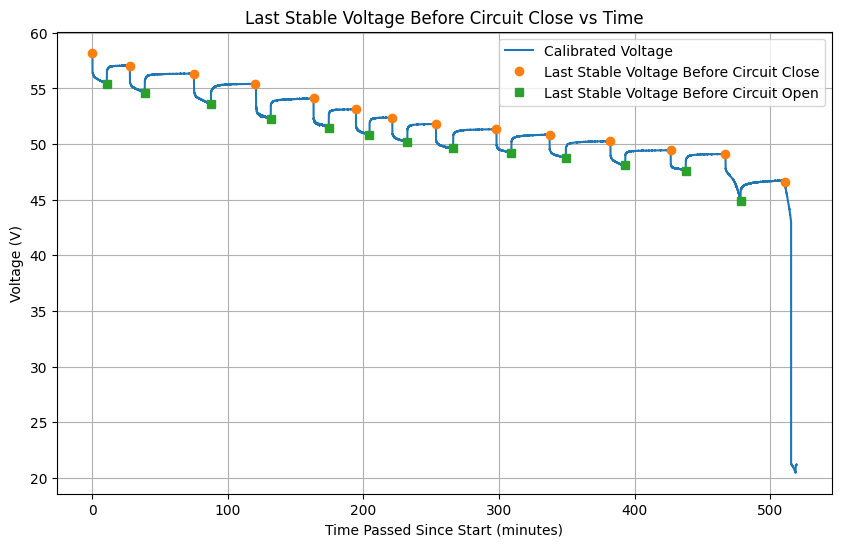

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Voltage'], label='Calibrated Voltage')
plt.plot(last_stable_voltages_before_close['time'], last_stable_voltages_before_close['voltage'], 'o', label='Last Stable Voltage Before Circuit Close')
plt.plot(last_stable_voltages_before_open['time'], last_stable_voltages_before_open['voltage'], 's', label='Last Stable Voltage Before Circuit Open')
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Last Stable Voltage Before Circuit Close vs Time')
plt.legend()
plt.grid()
plt.show()

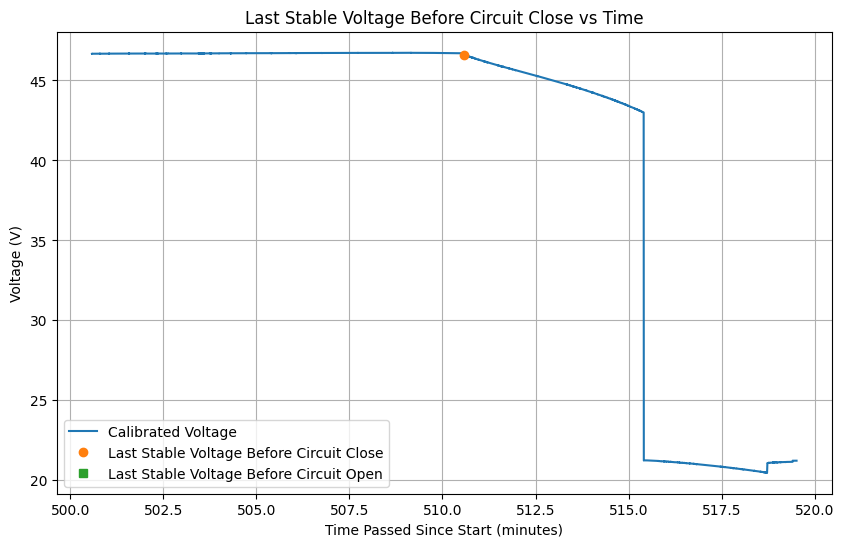

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'][600000:], combined_df['Calibrated Voltage'][600000:], label='Calibrated Voltage')
plt.plot(last_stable_voltages_before_close['time'][13:], last_stable_voltages_before_close['voltage'][13:], 'o', label='Last Stable Voltage Before Circuit Close')
plt.plot(last_stable_voltages_before_open['time'][13:], last_stable_voltages_before_open['voltage'][13:], 's', label='Last Stable Voltage Before Circuit Open')
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Last Stable Voltage Before Circuit Close vs Time')
plt.legend()
plt.grid()
plt.show()

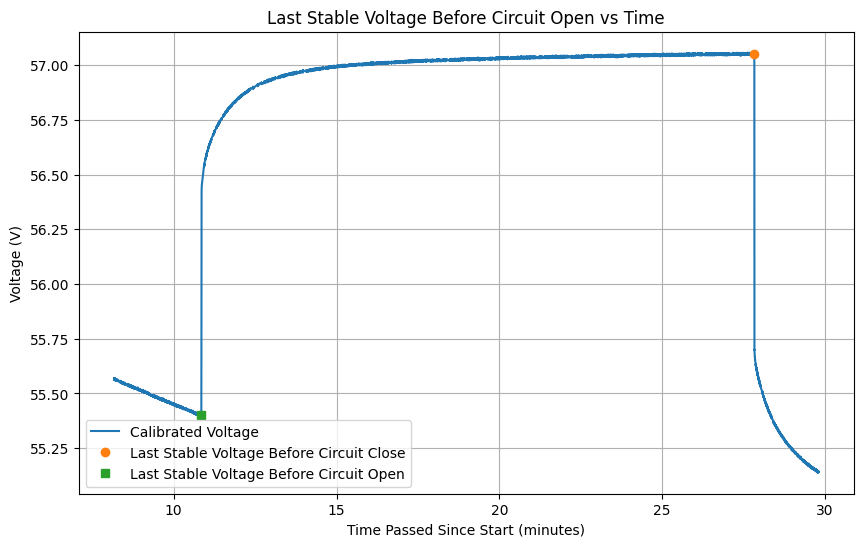

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'][10000:35000], combined_df['Calibrated Voltage'][10000:35000], label='Calibrated Voltage')
plt.plot(last_stable_voltages_before_close['time'][1:2], last_stable_voltages_before_close['voltage'][1:2], 'o', label='Last Stable Voltage Before Circuit Close')
plt.plot(last_stable_voltages_before_open['time'][0], last_stable_voltages_before_open['voltage'][0], 's', label='Last Stable Voltage Before Circuit Open')
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Last Stable Voltage Before Circuit Open vs Time')
plt.legend()
plt.grid()
plt.show()

Index before jump: -1, Index after jump: -1


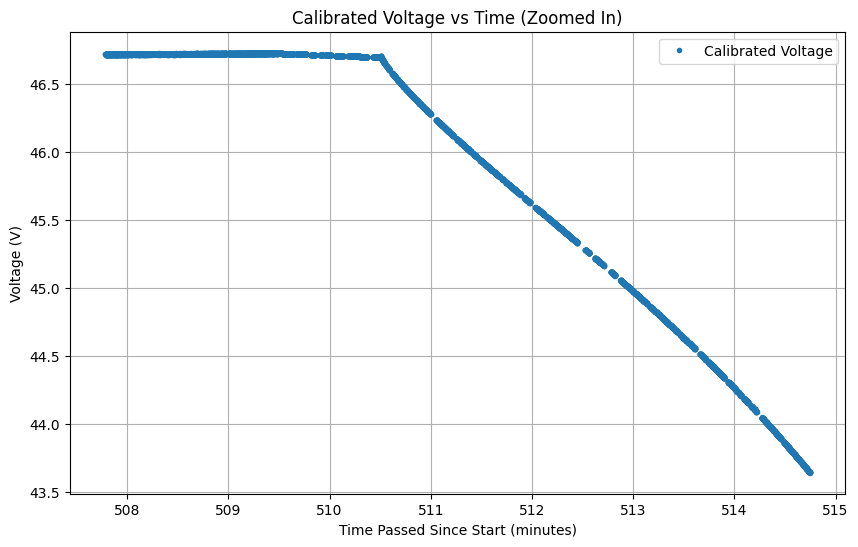

In [25]:
# Visual inspection of anormally

before_jump = -1
index_before_jump = -1
index_after_jump = -1

for index in range(610000, len(combined_df)-1):
    curr = combined_df['Calibrated Voltage'].iloc[index]
    prev = combined_df['Calibrated Voltage'].iloc[index-1]
    if before_jump == -1 and curr - prev > 1:
        before_jump = prev
        index_before_jump = index - 1
        print(f"Found voltage jump at index {index} from {before_jump:.2f} V to {curr:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
    if curr < before_jump:
        index_after_jump = index
        print(f"Voltage dropped back down at index {index} from {curr:.2f} V to {combined_df['Calibrated Voltage'].iloc[index]:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
        break
print(f"Index before jump: {index_before_jump}, Index after jump: {index_after_jump}")

plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'][610000:618000], combined_df['Calibrated Voltage'][610000:618000], '.', label='Calibrated Voltage', )
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Calibrated Voltage vs Time (Zoomed In)')
plt.legend()
plt.grid()

In [24]:
if index_before_jump != -1 and index_after_jump != -1:
    # Shift the voltage down
    voltage_before_jump = combined_df['Calibrated Voltage'].iloc[index_before_jump-20:index_before_jump].mean()
    voltage_after_jump = combined_df['Calibrated Voltage'].iloc[index_after_jump:index_after_jump+20].mean()
    print(f"Voltage before jump: {voltage_before_jump:.2f} V, Voltage after jump: {voltage_after_jump:.2f} V")
    
    m = (voltage_after_jump - voltage_before_jump) / (combined_df['Translated Time (minutes)'][index_after_jump] - combined_df['Translated Time (minutes)'][index_before_jump])
    c = voltage_before_jump - m * combined_df['Translated Time (minutes)'][index_before_jump]
    
    for index in range(index_before_jump, index_after_jump):
        new_voltage = m * combined_df['Translated Time (minutes)'][index] + c
        combined_df.loc[index, 'Calibrated Voltage'] = new_voltage
    
    index_before_jump = -1
    index_after_jump = -1
else:
    print("Did not find a valid voltage jump to correct.")

Voltage before jump: 46.73 V, Voltage after jump: 46.70 V


In [52]:
create_csv_output_file(override=True, csv_data=combined_df)

In [53]:
outpus_json_points = {
    "before_close": {
        "index": last_stable_voltages_before_close['index'],
        "time": last_stable_voltages_before_close['time'],
        "voltage": last_stable_voltages_before_close['voltage']
    },
    "before_open": {
        "index": last_stable_voltages_before_open['index'],
        "time": last_stable_voltages_before_open['time'],
        "voltage": last_stable_voltages_before_open['voltage']
    }
}
print(f"Saved {len(last_stable_voltages_before_close['index'])} points for before close and {len(last_stable_voltages_before_open['time'])} points for before open to {points_of_interest_file_name}.")
json.dump(outpus_json_points, open(points_of_interest_file_name, 'w'), indent=4)

Saved 14 points for before close and 13 points for before open to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\points_of_interest.json.
